🔍 INSPECTING: volume_100_slice_83.h5
Image -> Shape: (240, 240, 4), Type: float64
Mask  -> Shape: (240, 240, 3), Type: uint8, Unique values: [0 1]
--------------------------------------------------
🛠️ Detected multi-channel mask. Combining channels for visualization...


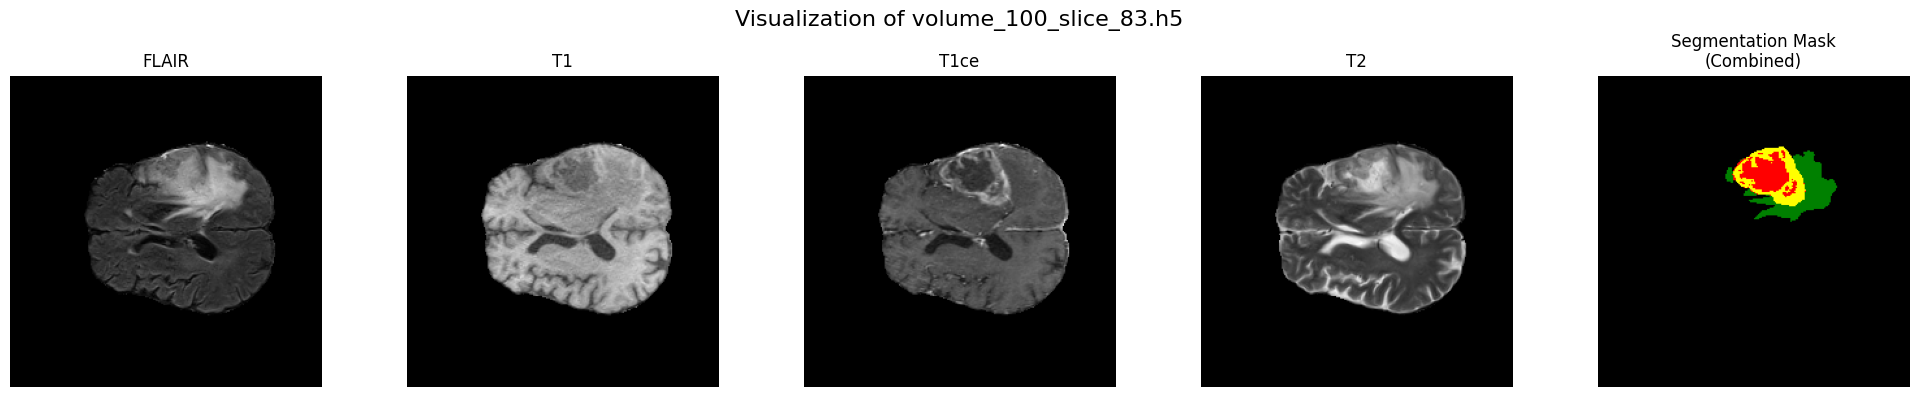

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os

def visualize_brats_slice_debug(h5_file_path):
    with h5py.File(h5_file_path, 'r') as f:
        image = np.array(f['image'])
        mask = np.array(f['mask'])
        
        # --- 1. THE DETECTIVE WORK ---
        print(f"🔍 INSPECTING: {os.path.basename(h5_file_path)}")
        print(f"Image -> Shape: {image.shape}, Type: {image.dtype}")
        print(f"Mask  -> Shape: {mask.shape}, Type: {mask.dtype}, Unique values: {np.unique(mask)}")
        print("-" * 50)
        
        # --- 2. SQUASHING THE MASK (If necessary) ---
        mask_to_plot = np.zeros((240, 240)) # Default blank 2D canvas
        
        # Case A: Mask is One-Hot Encoded (e.g., 240 x 240 x 3)
        if len(mask.shape) == 3 and mask.shape[-1] in [3, 4]:
            print("🛠️ Detected multi-channel mask. Combining channels for visualization...")
            # Assign a unique integer (1, 2, 3) to each channel so we can color-code them
            for channel_idx in range(mask.shape[-1]):
                mask_to_plot[mask[:, :, channel_idx] > 0] = channel_idx + 1
                
        # Case B: Mask is Channels-First (e.g., 3 x 240 x 240)
        elif len(mask.shape) == 3 and mask.shape[0] in [3, 4]:
            print("🛠️ Detected channels-first multi-channel mask. Combining...")
            for channel_idx in range(mask.shape[0]):
                mask_to_plot[mask[channel_idx, :, :] > 0] = channel_idx + 1
                
        # Case C: Mask is already 2D flat (240 x 240)
        elif len(mask.shape) == 2:
            print("🛠️ Detected standard 2D mask. Mapping labels...")
            mask_to_plot = mask.copy()
            mask_to_plot[mask_to_plot == 4] = 3 # Remap 4 to 3 for our colormap
            
        else:
            print(f"⚠️ Unrecognized mask shape: {mask.shape}")

        # --- 3. PLOTTING ---
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        modalities = ['FLAIR', 'T1', 'T1ce', 'T2']
        
        for i in range(4):
            img_channel = image[:, :, i] if image.shape[-1] == 4 else image[i, :, :]
            axes[i].imshow(img_channel, cmap='gray')
            axes[i].set_title(modalities[i])
            axes[i].axis('off')
            
        # Plot our freshly combined mask
        brats_cmap = ListedColormap(['black', 'red', 'green', 'yellow'])
        axes[4].imshow(mask_to_plot, cmap=brats_cmap, vmin=0, vmax=3) 
        axes[4].set_title('Segmentation Mask\n(Combined)')
        axes[4].axis('off')
        
        plt.suptitle(f"Visualization of {os.path.basename(h5_file_path)}", fontsize=16)
        plt.tight_layout()
        plt.show()

# Run it on your confirmed good slice!
base_dir = "/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data"
good_slice_path = os.path.join(base_dir, "volume_100_slice_83.h5")

visualize_brats_slice_debug(good_slice_path)

/tmp/ipykernel_57/645352094.py:75: UserWarning: The CUDA compiler succeeded, but said the following:
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).

  mod = SourceModule(cuda_code)


Data Shape: (240, 240) -> Flattened: 57600 pixels
CUDA Config: Grid(225), Block(256)
⏱️ Naive K-Means took: 0.0139 seconds
⏱️ Shared Memory K-Means took: 0.0073 seconds


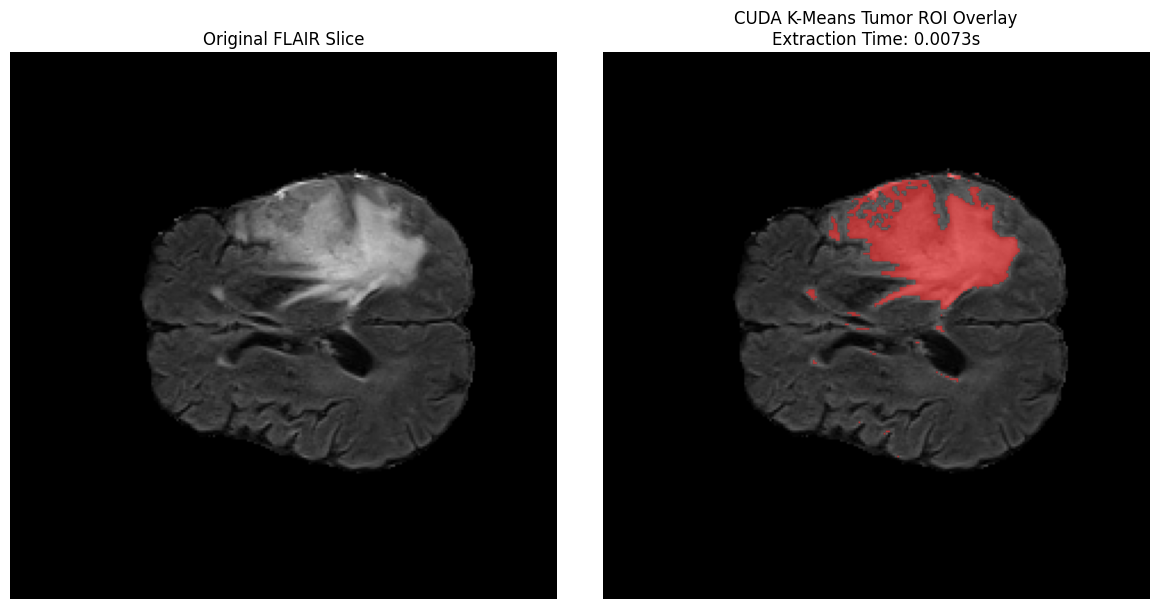

In [1]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
from matplotlib.colors import ListedColormap

# =====================================================================
# 1. CUDA C++ KERNELS
# =====================================================================
cuda_code = """
// ---------------------------------------------------------
// Kernel 1: Naive Parallel Lloyd's Algorithm
// Every thread reads centroids from Global Memory.
// ---------------------------------------------------------
__global__ void kmeans_assign_naive(float *pixels, float *centroids, int *labels, int num_pixels, int k) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    
    if (idx < num_pixels) {
        float pixel_val = pixels[idx];
        float min_dist = 1e9;
        int best_cluster = 0;
        
        // Loop through all centroids in GLOBAL memory
        for (int i = 0; i < k; i++) {
            float dist = abs(pixel_val - centroids[i]); // 1D distance (intensity)
            if (dist < min_dist) {
                min_dist = dist;
                best_cluster = i;
            }
        }
        labels[idx] = best_cluster;
    }
}

// ---------------------------------------------------------
// Kernel 2: Tiled K-Means with Shared Memory
// Threads load centroids into fast Shared Memory first.
// ---------------------------------------------------------
__global__ void kmeans_assign_shared(float *pixels, float *centroids, int *labels, int num_pixels, int k) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int tid = threadIdx.x;
    
    // Dynamically allocated shared memory for centroids
    extern __shared__ float shared_centroids[];
    
    // The first 'k' threads in the block load the centroids into shared memory
    if (tid < k) {
        shared_centroids[tid] = centroids[tid];
    }
    
    // Make sure all centroids are loaded before any thread proceeds
    __syncthreads();
    
    if (idx < num_pixels) {
        float pixel_val = pixels[idx];
        float min_dist = 1e9;
        int best_cluster = 0;
        
        // Loop through centroids in incredibly fast SHARED memory
        for (int i = 0; i < k; i++) {
            float dist = abs(pixel_val - shared_centroids[i]);
            if (dist < min_dist) {
                min_dist = dist;
                best_cluster = i;
            }
        }
        labels[idx] = best_cluster;
    }
}
"""

mod = SourceModule(cuda_code)
naive_kernel = mod.get_function("kmeans_assign_naive")
shared_kernel = mod.get_function("kmeans_assign_shared")

# =====================================================================
# 2. LOAD DATA & INITIALIZE
# =====================================================================
# Load your specific slice
file_path = "/kaggle/input/datasets/awsaf49/brats2020-training-data/BraTS2020_training_data/content/data/volume_100_slice_83.h5"
with h5py.File(file_path, 'r') as f:
    image = np.array(f['image'])
    # Grab just the FLAIR channel (channel 0)
    flair = image[:, :, 0] if image.shape[-1] == 4 else image[0, :, :]

# Flatten the 2D image into a 1D array for the GPU
pixels = flair.flatten().astype(np.float32)
num_pixels = np.int32(len(pixels))
K = np.int32(4) # 4 Clusters: Background, Core, Edema, Enhancing

# Initialize random centroids
np.random.seed(42)
centroids = np.random.choice(pixels, K).astype(np.float32)
labels_out = np.zeros_like(pixels, dtype=np.int32)

# GPU Grid/Block setup
block_size = 256
grid_size = int(np.ceil(num_pixels / block_size))

print(f"Data Shape: {flair.shape} -> Flattened: {num_pixels} pixels")
print(f"CUDA Config: Grid({grid_size}), Block({block_size})")

# =====================================================================
# 3. EXECUTE & TIME NAIVE ALGORITHM
# =====================================================================
start_time = time.time()

# Run 10 iterations of K-Means
for iteration in range(10):
    # GPU: Assign pixels to nearest centroid
    naive_kernel(
        cuda.In(pixels), 
        cuda.In(centroids), 
        cuda.Out(labels_out), 
        num_pixels, K,
        block=(block_size, 1, 1), grid=(grid_size, 1)
    )
    
    # CPU: Update centroids based on new labels
    for i in range(K):
        cluster_pixels = pixels[labels_out == i]
        if len(cluster_pixels) > 0:
            centroids[i] = np.mean(cluster_pixels)

naive_time = time.time() - start_time
print(f"⏱️ Naive K-Means took: {naive_time:.4f} seconds")

# =====================================================================
# 4. EXECUTE & TIME SHARED MEMORY ALGORITHM
# =====================================================================
# Reset centroids and output array
centroids = np.random.choice(pixels, K).astype(np.float32)
labels_out_shared = np.zeros_like(pixels, dtype=np.int32)
# Shared memory needs to know how many bytes to allocate: K * size of float (4 bytes)
shared_mem_size = int(K * 4) 

start_time = time.time()

for iteration in range(10):
    shared_kernel(
        cuda.In(pixels), 
        cuda.In(centroids), 
        cuda.Out(labels_out_shared), 
        num_pixels, K,
        block=(block_size, 1, 1), grid=(grid_size, 1),
        shared=shared_mem_size # Pass shared memory size here!
    )
    
    for i in range(K):
        cluster_pixels = pixels[labels_out_shared == i]
        if len(cluster_pixels) > 0:
            centroids[i] = np.mean(cluster_pixels)

shared_time = time.time() - start_time
print(f"⏱️ Shared Memory K-Means took: {shared_time:.4f} seconds")

# =====================================================================
# 5. VISUALIZE THE RESULTS
# =====================================================================

# 2. Fix the random K-Means colors by sorting centroids by intensity
# Get the final centroid values
final_centroids = centroids.copy()
# Find the order that sorts them from darkest (background) to brightest (tumor)
sorted_indices = np.argsort(final_centroids)

label_mapping = {old_label: new_label for new_label, old_label in enumerate(sorted_indices)}
# Apply the mapping to our shared memory output
ordered_labels = np.vectorize(label_mapping.get)(labels_out_shared)
ordered_image = ordered_labels.reshape((240, 240))

# 1. We know from our sorted mapping that the tumor is Label 3.
# Let's isolate it by creating a "masked array" where everything that ISN'T 3 becomes invisible.
tumor_only_mask = np.ma.masked_where(ordered_image != 3, ordered_image)


# Create a colormap that only has one color: Red
red_cmap = ListedColormap(['red'])

# 2. Plot the Professional Overlay
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left Image: The clean, original MRI
axes[0].imshow(flair, cmap='gray')
axes[0].set_title("Original FLAIR Slice")
axes[0].axis('off')

# Right Image: The Original MRI + The Semi-Transparent Tumor Mask
axes[1].imshow(flair, cmap='gray') # Draw the brain first
axes[1].imshow(tumor_only_mask, cmap=red_cmap, alpha=0.5) # Draw the red mask on top (50% transparent)
axes[1].set_title(f"CUDA K-Means Tumor ROI Overlay\nExtraction Time: {shared_time:.4f}s")
axes[1].axis('off')

plt.tight_layout()
plt.show()